In [ ]:
import pandas as pd
import seaborn as sb 
import matplotlib.pyplot as plt
import os,sys
import pandas as pd
from matplotlib.lines import Line2D
import matplotlib as mpl
import numpy as np
import pingouin as pg
from scipy.stats import zscore
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P'])
from rois.rois import remove_bad_cells
plt.style.use('/Users/amonast/Documents/GitHub/Amy_Reviews/paper_style.mplstyle')

savepath = '/Users/amonast/BOSTON UNIVERSITY Dropbox/Amy Monasterio/Manuscripts/Engram2P/Figures/RevisionFigures/Figure1-Supp1-2/plots'

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


# Calculate mCherry intensities.

In [2]:
base_dir = '/Volumes/AM_SSD1/Spont2P'
file_key = '/Volumes/AM_SSD1/Spont2P/Data_info.csv'
animals = ['589L',
            '989N',
            '992N',
            '992L',
            '994R',
            '9972R',
            '217R',
            '217N',
            '218L',
            '034R',
            '149L',
            '146R',
            '160R',
            '492N',
            '493R',
            '1912L']
fov_lists = [['FOV1','FOV2'],
            ['FOV1','FOV2'],
            ['FOV2'],
            ['FOV2'],
            ['FOV1','FOV2'],
            ['FOV1','FOV2'],
            ['FOV1'],
            ['FOV1','FOV2'],
            ['FOV1','FOV2'],
            ['FOV1'],
            ['FOV1','FOV2'],
            ['FOV2'],
            ['FOV1','FOV2'],
            ['FOV1','FOV2'],
            ['FOV1'],
            ['FOV1','FOV2']]

info = pd.read_csv(file_key)
DF = pd.DataFrame()
for a,ani in enumerate(animals):
    fovs = fov_lists[a]
    for fov in fovs:
        ind_df = remove_bad_cells(ani,fov,file_key,base_dir,snr_thr=4.0,filter_mchleak=True)
        ind_df = ind_df.loc[(ind_df.Baseline!=-1) & (ind_df.Post!=-1)]
        group = info.Group.loc[info.Animal==ani].values[0]
        ind_df['FOV']=[fov]*len(ind_df)
        ind_df['Animal']=[ani]*len(ind_df)
        ind_df['Group'] = [group]*len(ind_df)
        zscored=zscore(np.concatenate((ind_df.mch_pre,ind_df.mch_post)))
        ind_df['mch_Z_pre']= zscored[0:int(len(zscored)/2)]
        ind_df['mch_Z_post']= zscored[0:int(len(zscored)/2)]
        DF = pd.concat([DF,ind_df],ignore_index=True)

# mch_pre = [float(DF['mch_pre'].values[i][1:-1]) for i in range(len(DF))]
# mch_post =  [float(DF['mch_post'].values[i][1:-1]) for i in range(len(DF))]

DF_reg1 = DF.loc[(DF.Baseline!=-1)&(DF.Post!=-1)]

/Volumes/AM_SSD1/Spont2P/Tagging/589L_FOV1_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/589L_FOV1/cellRegistered_20220111_145423.mat
356 Cells detected in registration
245 Cells detected in session 1 of 2
259 Cells detected in session 2 of 2
dropped leaky cell
dropped leaky cell
dropped leaky cell
dropped leaky cell
356 cells filtered to 256cells
/Volumes/AM_SSD1/Spont2P/Tagging/589L_FOV2_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/589L_FOV2/cellRegistered_20220111_145726.mat
326 Cells detected in registration
218 Cells detected in session 1 of 2
216 Cells detected in session 2 of 2
dropped leaky cell
dropped leaky cell
326 cells filtered to 157cells
/Volumes/AM_SSD1/Spont2P/Tagging/989N_FOV1_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/989N_FOV1/cellRegistered_20220613_225153.mat
378 Cells detected in registration
260 Cells detected in session 1 of 2
253 Cells detected in session 2 o

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/3328804118.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_df['FOV']=[fov]*len(ind_df)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/3328804118.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_df['Animal']=[ani]*len(ind_df)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/3328804118.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

265 Cells detected in session 1 of 2
228 Cells detected in session 2 of 2
dropped leaky cell
dropped leaky cell
dropped leaky cell
dropped leaky cell
368 cells filtered to 224cells
/Volumes/AM_SSD1/Spont2P/Tagging/992N_FOV2_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/992N_FOV2/cellRegistered_20220111_153709.mat
368 Cells detected in registration


/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/3328804118.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_df['FOV']=[fov]*len(ind_df)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/3328804118.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_df['Animal']=[ani]*len(ind_df)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/3328804118.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

239 Cells detected in session 1 of 2
245 Cells detected in session 2 of 2
dropped leaky cell
dropped leaky cell
dropped leaky cell
368 cells filtered to 305cells
/Volumes/AM_SSD1/Spont2P/Tagging/992L_FOV2_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/992L_FOV2/cellRegistered_20231204_154713.mat
348 Cells detected in registration


...

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/3328804118.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_df['FOV']=[fov]*len(ind_df)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/3328804118.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_df['Animal']=[ani]*len(ind_df)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/3328804118.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

171 Cells detected in session 1 of 2
162 Cells detected in session 2 of 2
dropped leaky cell
dropped leaky cell
dropped leaky cell
dropped leaky cell
239 cells filtered to 184cells
/Volumes/AM_SSD1/Spont2P/Tagging/1912L_FOV2_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/1912L_FOV2/cellRegistered_20241201_191846.mat
223 Cells detected in registration


/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/3328804118.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_df['FOV']=[fov]*len(ind_df)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/3328804118.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_df['Animal']=[ani]*len(ind_df)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/3328804118.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

157 Cells detected in session 1 of 2
161 Cells detected in session 2 of 2
dropped leaky cell
dropped leaky cell
223 cells filtered to 175cells


/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/3328804118.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_df['FOV']=[fov]*len(ind_df)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/3328804118.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_df['Animal']=[ani]*len(ind_df)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/3328804118.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

## Save CSV

In [3]:
DF.to_csv('mcherry_intensities_all.csv')

## Make dataframe

In [4]:
DF_reg1=DF.copy()
DF_reg = pd.concat([DF_reg1.loc[:,['Baseline','Post','Tagged','Animal','FOV','Group']],DF_reg1.loc[:,['Baseline','Post','Tagged','Animal','FOV','Group']]],ignore_index=True)
DF_reg['Session'] = ['Day 0']*len(DF_reg1)+['Day 4']*len(DF_reg1)
ints = np.concatenate((DF_reg1.mch_pre.values,DF_reg1.mch_post.values))
zscored=np.concatenate((DF_reg1.mch_Z_pre.values,DF_reg1.mch_Z_post.values))
DF_reg['mCherryInt'] = ints
DF_reg['ZScoredInt']=zscored
DF_reg['ZScoreAllCell']=zscore(DF_reg.mCherryInt)
DF_reg

,Baseline,Post,Tagged,Animal,FOV,Group,Session,mCherryInt,ZScoredInt,ZScoreAllCell
0,4,2,1,589L,FOV1,HC,Day 0,16.560293,-0.522408,-0.498129
1,5,5,0,589L,FOV1,HC,Day 0,13.310050,-0.693841,-0.578225
2,7,7,0,589L,FOV1,HC,Day 0,14.528449,-0.629577,-0.548200
3,11,9,0,589L,FOV1,HC,Day 0,10.403583,-0.847141,-0.649850
4,13,12,1,589L,FOV1,HC,Day 0,13.925578,-0.661375,-0.563057
...,...,...,...,...,...,...,...,...,...,...
4993,151,84,0,1912L,FOV2,HC,Day 4,151.101200,-0.062417,2.817379
4994,152,35,0,1912L,FOV2,HC,Day 4,81.249110,-0.751080,1.096005
4995,153,86,0,1912L,FOV2,HC,Day 4,83.997090,-0.696966,1.163724
4996,154,78,1,1912L,FOV2,HC,Day 4,181.980900,-0.451001,3.578351


# Supp Fig 1C 

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/4284015609.py:7: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim([0,500])


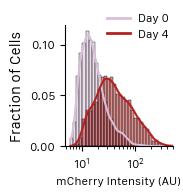

In [ ]:
plt.figure(figsize=(2,2))
ax=plt.gca()
g=sb.histplot(data=DF_reg,x='mCherryInt',log_scale=True,hue='Session',ax=ax,stat='proportion',common_norm=False,kde=True,hue_order=['Day 4', 'Day 0'],palette={'firebrick','thistle'})
ax.set_xlim([0,500])
ax.set_xlabel('mCherry Intensity (AU)',fontdict={'size':8})
ax.set_ylabel('Fraction of Cells',fontdict={'size':10})
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
sb.despine()
lines = [Line2D([0], [0], color='thistle', lw=2),
        Line2D([0], [0], color='firebrick', lw=2)]
ax.legend(lines,['Day 0','Day 4'],bbox_to_anchor=(.3,.8),frameon=False,fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(savepath,'mch_intensity_regcells_all_hist.svg'),dpi=300,transparent=True)

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_38417/366350154.py:13: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  plt.tight_layout()
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


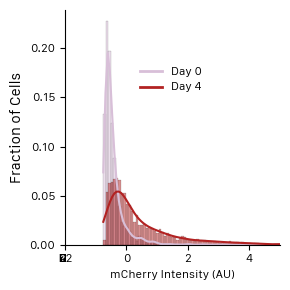

In [7]:
plt.figure(figsize=(3,3))
ax=plt.gca()
g=sb.histplot(data=DF_reg,x='ZScoreAllCell',log_scale=False,hue='Session',ax=ax,stat='proportion',common_norm=False,kde=True,hue_order=['Day 4', 'Day 0'],palette={'firebrick','thistle'})
ax.set_xlabel('mCherry Intensity (AU)',fontdict={'size':8})
ax.set_ylabel('Fraction of Cells',fontdict={'size':10})
plt.xlim([-2,5])
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
sb.despine()
lines = [Line2D([0], [0], color='thistle', lw=2),
        Line2D([0], [0], color='firebrick', lw=2)]
ax.legend(lines,['Day 0','Day 4'],bbox_to_anchor=(.3,.8),frameon=False,fontsize=8)
plt.tight_layout()

In [8]:
pg.wilcoxon(DF_reg.mCherryInt.loc[(DF_reg.Session=='Day 0')].values,
       DF_reg.mCherryInt.loc[(DF_reg.Session=='Day 4')].values)

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,119.0,two-sided,0.0,-0.999924,0.169273


# Supp Fig 1D

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_44259/1336774200.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


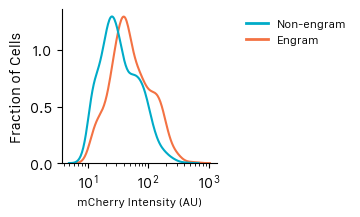

In [ ]:
plt.figure(figsize=(2,2))
ax=plt.gca()
g=sb.kdeplot(data=DF_reg.loc[(DF_reg.Session=='Day 4')],x='mCherryInt',log_scale=True,hue='Tagged',ax=ax,common_norm=False,hue_order=[0,1],palette=['#00ABC8','#F37243'])
# ax.set_xlim([0,200])
# ax.set_ylim([0,.05])

ax.set_xlabel('mCherry Intensity (AU)',fontdict={'size':8})
ax.set_ylabel('Fraction of Cells',fontdict={'size':10})
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)
sb.despine()
lines = [Line2D([0], [0], color='#00ABC8', lw=2),
        Line2D([0], [0], color='#F37243', lw=2)]
ax.legend(lines,['Non-engram','Engram'],bbox_to_anchor=(1.9,1),loc='upper right',frameon=False,fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(savepath,'mch_intensityD4_regcells_split_kde_log.svg'),dpi=300,transparent=True)

In [ ]:
pg.normality(data=DF_reg.loc[DF_reg.Session=='Day 4'],dv='mCherryInt',group='Tagged')

,W,pval,normal
Tagged,,,
1,0.768837,2.154543e-34,False
0,0.746283,1.155610e-43,False


In [ ]:
pg.mwu(DF_reg.mCherryInt.loc[(DF_reg.Session=='Day 4')&(DF_reg.Tagged==1)].values,
       DF_reg.mCherryInt.loc[(DF_reg.Session=='Day 4')&(DF_reg.Tagged==0)].values)

,U-val,alternative,p-val,RBC,CLES
MWU,952681.0,two-sided,4.104648e-36,-0.299086,0.649543


# Supp Figure 1G

In [ ]:
fold_df = pd.DataFrame()
for ani in animals:
    df_ani = DF_reg.loc[DF_reg['Animal']==ani].reset_index(drop=True)
    tagged = df_ani['Tagged'].iloc[:int(df_ani.shape[0]/2)]
    group = [df_ani.Group.values[0]]*int(df_ani.Group.shape[0]/2)
    fold_change = df_ani['mCherryInt'].loc[df_ani['Session']=='Day 4'].values/df_ani['mCherryInt'].loc[df_ani['Session']=='Day 0'].values
    fold = pd.DataFrame()
    fold['Fold Change mCherry']=fold_change
    fold['ZScored Fold Change']=zscore(fold_change)
    fold['Animal']=[ani]*fold_change.shape[0]
    fold['Group']=group
    fold['Tagged']=tagged
    mean_fold = fold['Fold Change mCherry'].mean()
    fold['Normalized Fold Change mCherry'] = fold['Fold Change mCherry']/mean_fold
    fold['Normalized mCherry Int']  = df_ani['mCherryInt']/df_ani['mCherryInt'].loc[df_ani.Session=='Day 0'].mean()
    fold_df = pd.concat([fold_df,fold],ignore_index=True)

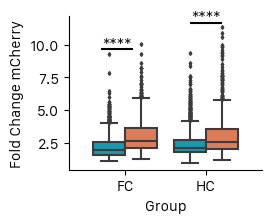

In [ ]:

plt.figure(figsize=(2.5,2))
sb.boxplot(data=fold_df,y='Fold Change mCherry',hue='Tagged',order=['FC','HC'],x='Group',palette=['#00ABC8','#F37243'],fliersize=2)
sb.despine()
plt.gca().get_legend().remove()
plt.hlines(9.7,-.3,.1,color='k')
plt.text(-.1,9.8,s='****',size=10,ha='center')
plt.hlines(11.7,.8,1.2,color='k')
plt.text(1,11.9,s='****',size=10,ha='center')


plt.savefig(os.path.join(savepath,'mch_foldchange_regcells_splitboxplots.svg'),dpi=300,transparent=True)

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


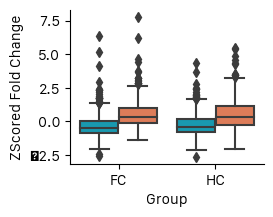

In [ ]:

plt.figure(figsize=(2.5,2))
sb.boxplot(data=fold_df,y='ZScored Fold Change',hue='Tagged',order=['FC','HC'],x='Group',palette=['#00ABC8','#F37243'],showfliers=True)
sb.despine()
plt.gca().get_legend().remove()
# plt.hlines(9.7,-.3,.1,color='k')
# plt.text(-.1,9.8,s='****',size=10,ha='center')
# plt.hlines(11.7,.8,1.2,color='k')
# plt.text(1,11.9,s='****',size=10,ha='center')



In [ ]:
pg.normality(data=fold_df,dv='Fold Change mCherry',group='Group')

,W,pval,normal
Group,,,
HC,0.753033,1.406173e-40,False
FC,0.829877,1.426170e-33,False


In [ ]:
pg.anova(data=fold_df,dv='Fold Change mCherry',between=['Group','Tagged'])

,Source,SS,DF,MS,F,p-unc,np2
0,Group,20.780308,1.0,20.780308,10.790278,1.034456e-03,0.004306
1,Tagged,321.421937,1.0,321.421937,166.899932,5.260182e-37,0.062700
2,Group * Tagged,1.219570,1.0,1.219570,0.633268,4.262349e-01,0.000254
3,Residual,4804.961427,2495.0,1.925836,NaN,NaN,NaN


In [ ]:
pg.pairwise_tests(data=fold_df,dv='Fold Change mCherry',between=['Group','Tagged'],padjust='bonf',parametric=False)

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pingouin/pairwise.py:382: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  stats.loc[:, "A"] = A
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pingouin/pairwise.py:383: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  stats.loc[:, "B"] = B
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pingouin/pairwise.py:583: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new

,Contrast,Group,A,B,Paired,Parametric,U-val,alternative,p-unc,p-corr,p-adjust,hedges
0,Group,-,FC,HC,False,False,737290.0,two-sided,2.451976e-02,NaN,NaN,-0.096582
1,Tagged,-,0,1,False,False,491118.0,two-sided,1.150448e-43,NaN,NaN,-0.524723
2,Group * Tagged,FC,0,1,False,False,101666.0,two-sided,6.430465e-30,1.286093e-29,bonf,-0.625147
3,Group * Tagged,HC,0,1,False,False,143761.0,two-sided,5.507890e-17,1.101578e-16,bonf,-0.467141


In [ ]:
ani_fold = fold_df.groupby(['Group','Animal','Tagged']).mean().reset_index()

# Supplementary Figure 1H

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_44259/2660249822.py:12: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  plt.savefig('mch_foldchange_animals_splitboxplot_zscore.svg',dpi=300,transparent=True)
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


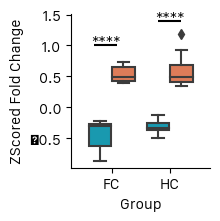

In [ ]:
mpl.rcParams['font.family']='Galvji'
mpl.rcParams['svg.fonttype']='none'
plt.figure(figsize=(1.8,2))
#sb.stripplot(data=ani_fold,y='Fold Change mCherry',hue='Tagged',order=['FC','HC'],x='Group',palette=['gray','gray'],dodge=True)
sb.boxplot(data=ani_fold,y='ZScored Fold Change',hue='Tagged',x='Group',palette=['#00ABC8','#F37243'],dodge=True)
plt.hlines(1,-.3,.1,color='k')
plt.text(-.1,1,s='****',size=10,ha='center')
plt.hlines(1.4,.8,1.2,color='k')
plt.text(1,1.4,s='****',size=10,ha='center')
sb.despine()
plt.gca().get_legend().remove()


plt.savefig(os.path.join(savepath,'mch_foldchange_animals_splitboxplot_zscore.svg'),dpi=300,transparent=True)

In [ ]:
pg.anova(data=ani_fold,dv='ZScored Fold Change',between=['Group','Tagged'])

,Source,SS,DF,MS,F,p-unc,np2
0,Group,0.072649,1,0.072649,1.639100,2.109541e-01,0.055302
1,Tagged,7.136397,1,7.136397,161.010623,3.946581e-13,0.851860
2,Group * Tagged,0.008132,1,0.008132,0.183464,6.716901e-01,0.006510
3,Residual,1.241031,28,0.044323,NaN,NaN,NaN


In [1]:
pg.pairwise_tests(data=ani_fold,dv='ZScored Fold Change',between=['Group','Tagged'],padjust='holm')

NameError: name 'pg' is not defined